In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

## Import the CSV data as pandas as DataFrame

In [53]:
df = pd.read_csv('data\StudentsPerformance.csv')

## Show top 5 records

In [54]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Shape of the dataset

In [55]:
df.shape

(1000, 8)

## Check missing values

In [56]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [57]:
df.duplicated().sum()

np.int64(0)

## Check data types

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Checking the no of unique values of each column

In [59]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

## Statistics of Dataset

In [60]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Exploring Data

In [61]:
print("Categories in 'gender' variable:   ", end=" ")
print(df['gender'].unique())

print("Categories in 'race/ethnicity' variable:   ", end=" ")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable:   ", end=" ")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable:   ", end=" ")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:   ", end=" ")
print(df['test preparation course'].unique())

Categories in 'gender' variable:    ['female' 'male']
Categories in 'race/ethnicity' variable:    ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable:    ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:    ['standard' 'free/reduced']
Categories in 'test preparation course' variable:    ['none' 'completed']


In [62]:
## Define numerical and categorical features

numeric_features = [feature for feature in df.columns if df[feature].dtype!= 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype=='O']

print("We have {} numerical features : {}". format(len(numeric_features), numeric_features))
print("We have {} categorical features : {}". format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [63]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Adding columns for "Total Score" and "Average"

In [64]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [65]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print(f"Number of students with full marks in Maths : {math_full}")
print(f"Number of students with full marks in writing : {writing_full}")
print(f"Number of students with full marks in reading : {reading_full}")

Number of students with full marks in Maths : 7
Number of students with full marks in writing : 14
Number of students with full marks in reading : 17


In [66]:
reading_less_20 = df[df['reading score'] <= 20]['average'].count()
writing_less_20 = df[df['writing score'] <= 20]['average'].count()
maths_less_20 = df[df['math score'] <= 20]['average'].count()

print(f"Number of students with less than 20 marks in Maths : {maths_less_20}")
print(f"Number of students with less than 20 marks in writing : {writing_less_20}")
print(f"Number of students with less than 20 marks in reading : {reading_less_20}")

Number of students with less than 20 marks in Maths : 4
Number of students with less than 20 marks in writing : 3
Number of students with less than 20 marks in reading : 1


## Histogram and KDE

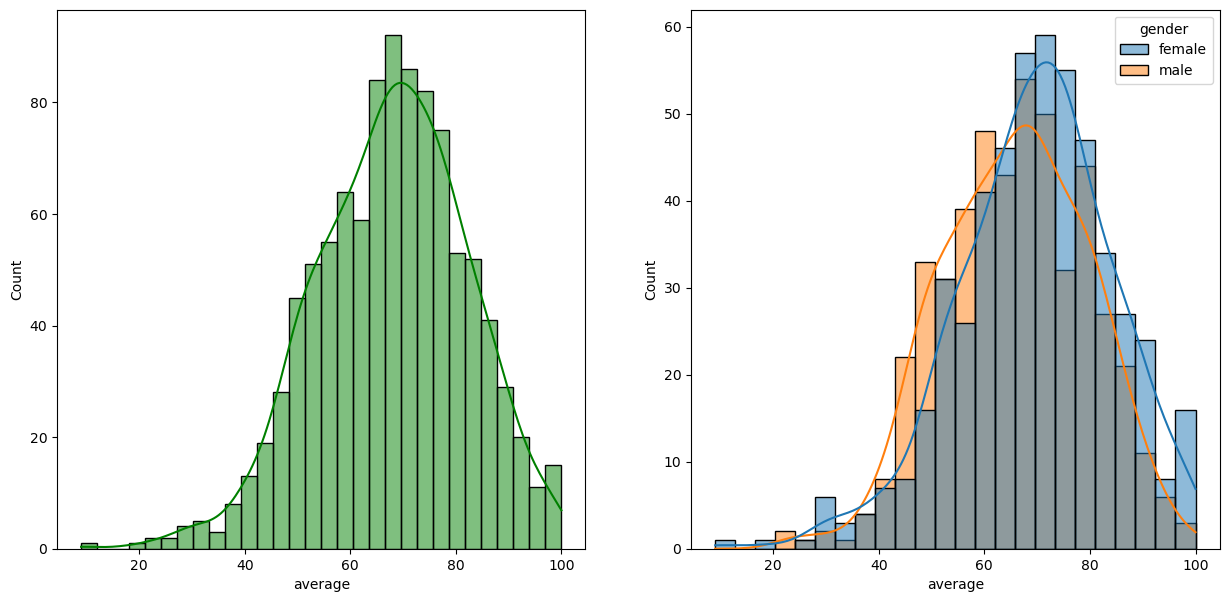

In [67]:
fig, axis= plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data = df, x='average', kde=True, hue='gender')
plt.show()

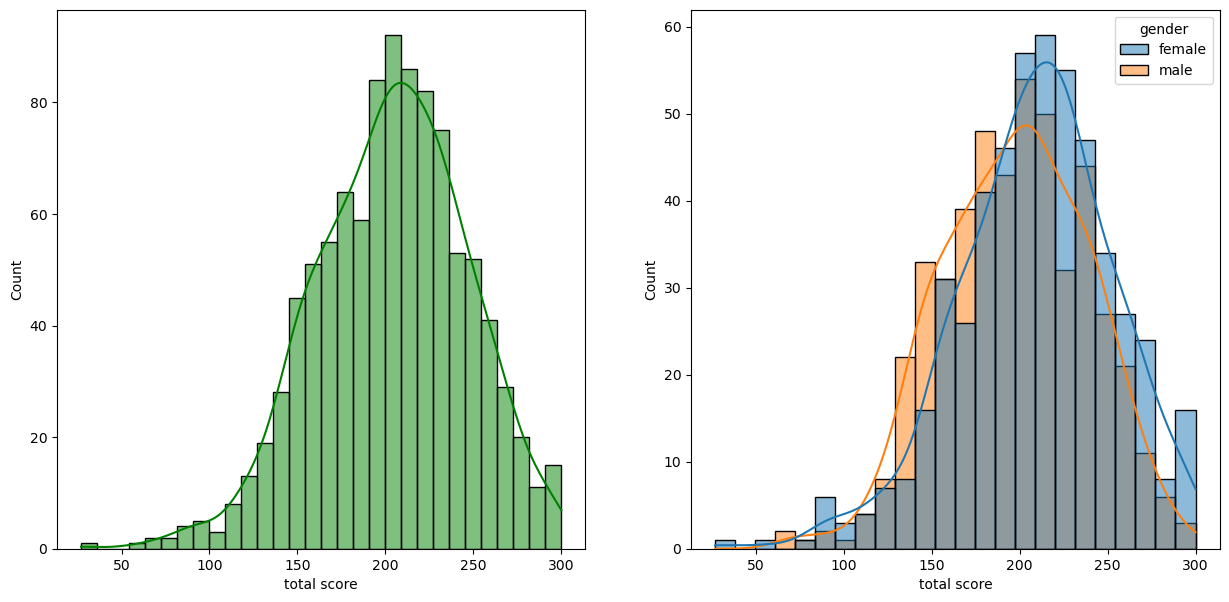

In [68]:
fig, axis= plt.subplots(1,2, figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df, x='total score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data = df, x='total score', kde=True, hue='gender')
plt.show()

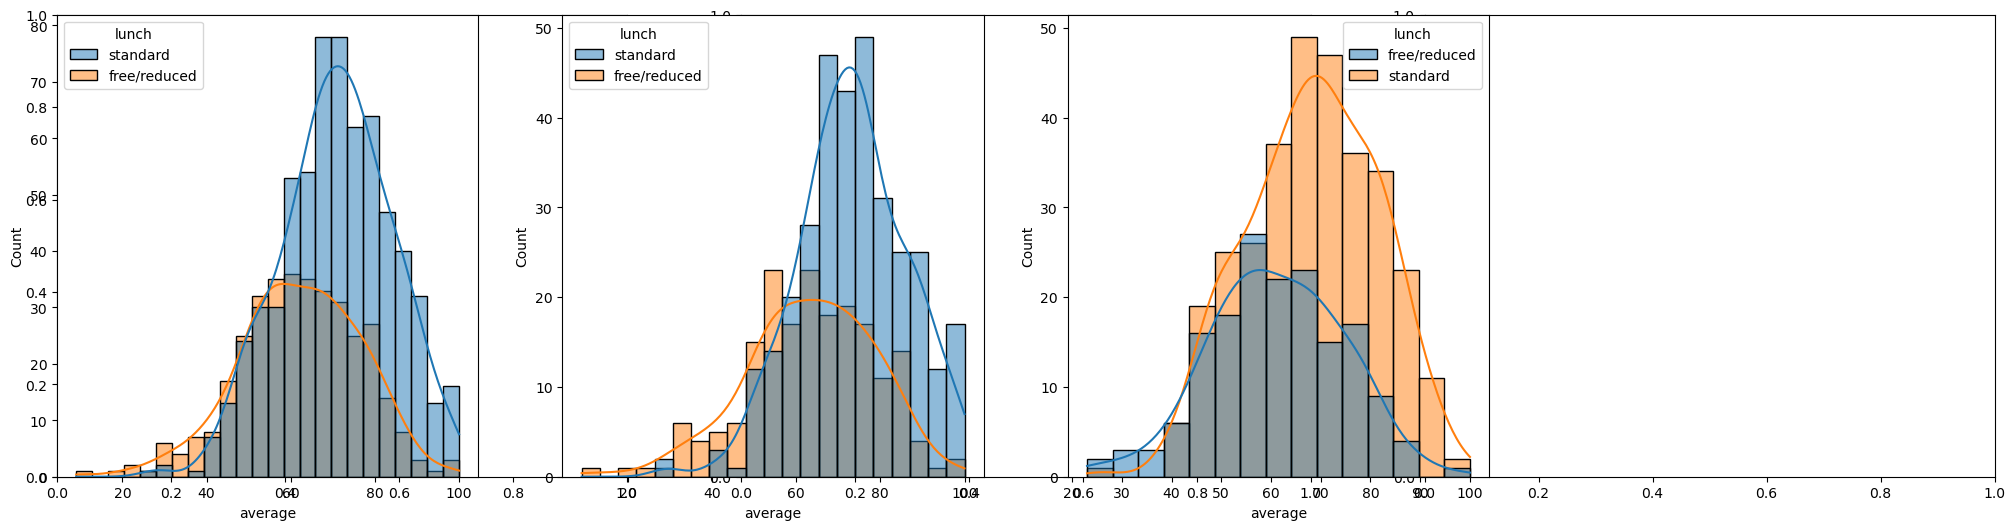

In [69]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='lunch')
plt.show()

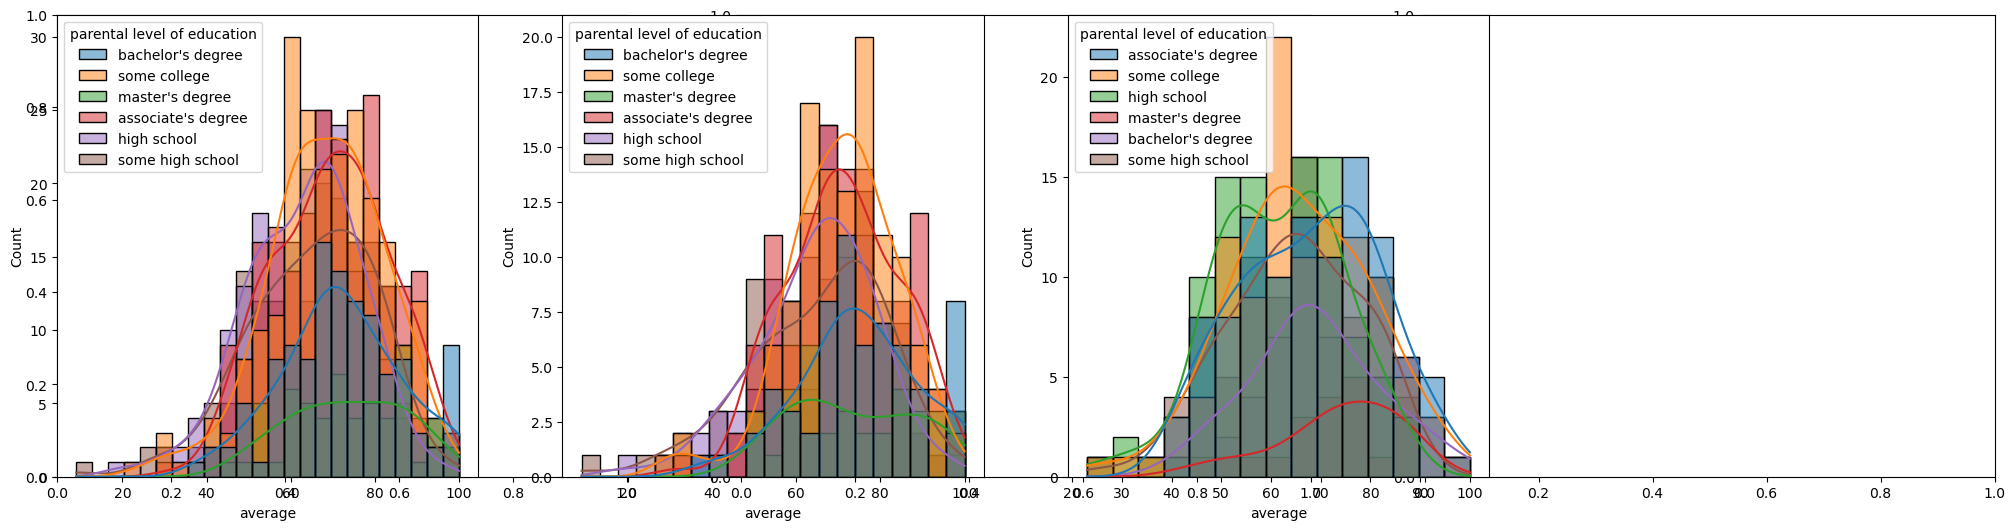

In [70]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='parental level of education')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='parental level of education')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='parental level of education')
plt.show()

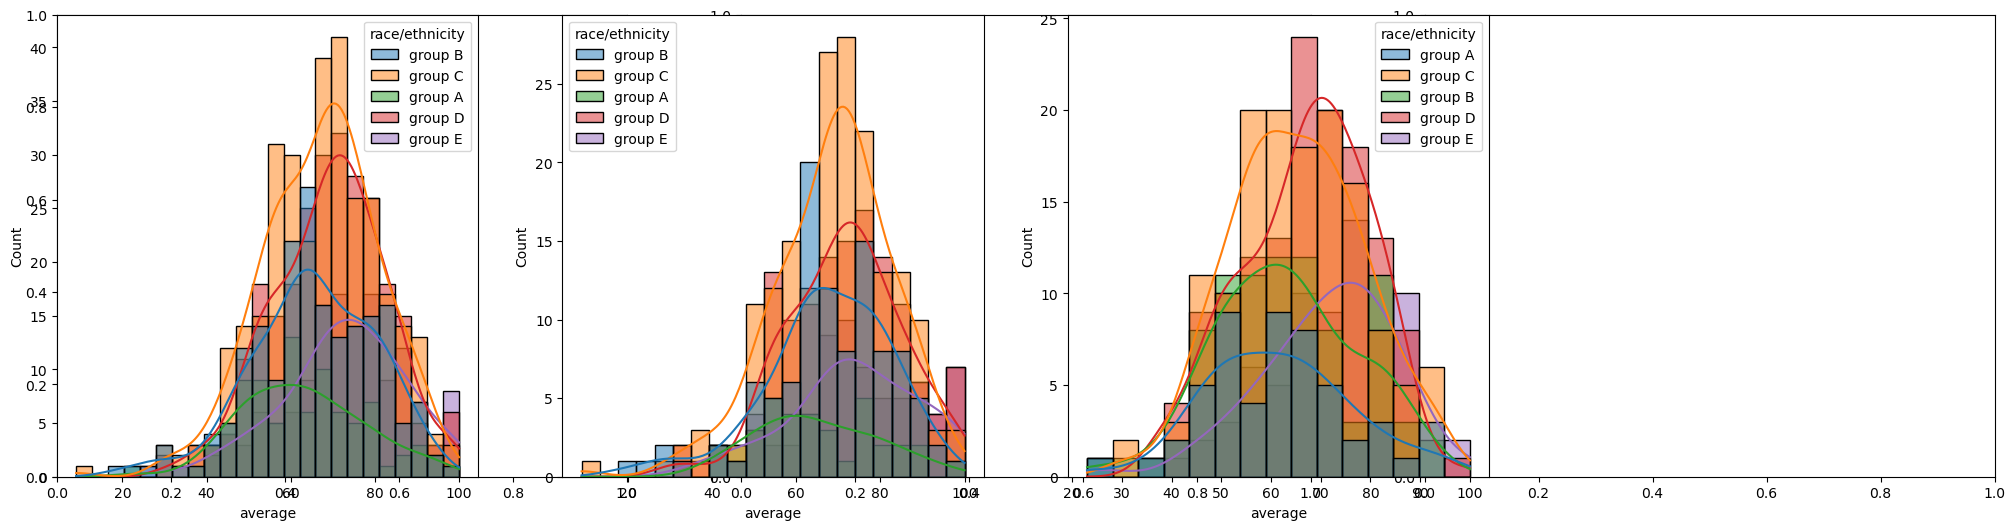

In [71]:
plt.subplots(1,3, figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')
plt.subplot(142)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='race/ethnicity')
plt.subplot(143)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='race/ethnicity')
plt.show()

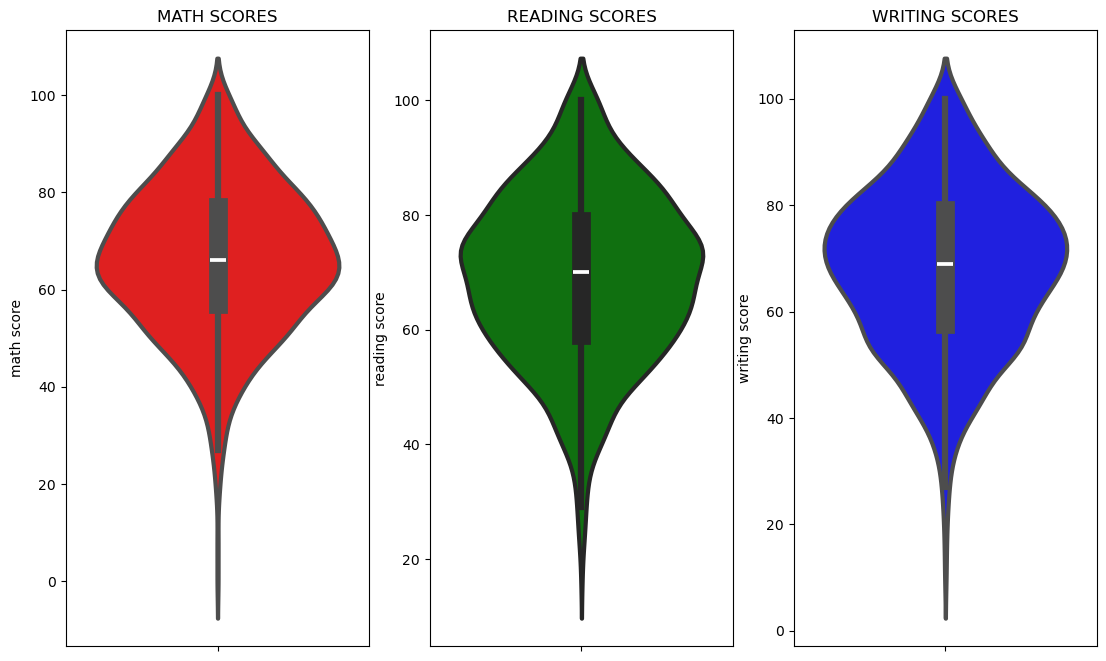

In [72]:
plt.figure(figsize=(18,8))
plt.subplot(1,4,1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, color= 'red', linewidth=3)
plt.subplot(1,4,2)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df, color= 'green', linewidth=3)
plt.subplot(1,4,3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df, color= 'blue', linewidth=3)
plt.show()

## Multivariate analysis using project

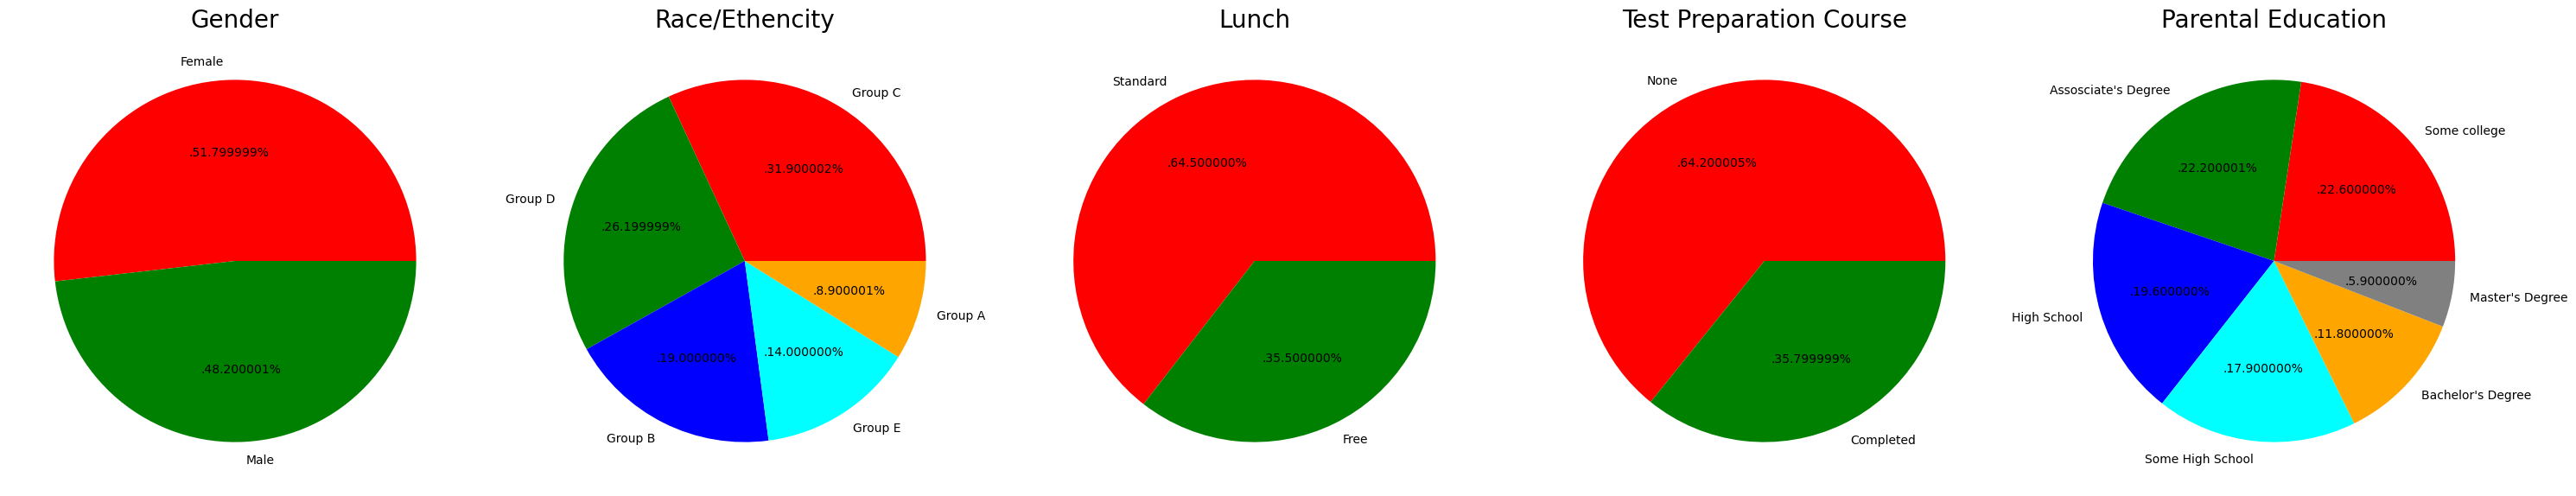

In [73]:
plt.rcParams['figure.figsize'] = (30,12)

plt.subplot(1,5,1)
size=df['gender'].value_counts()
labels= 'Female', 'Male'
color = ['red','green']

plt.pie(size, colors=color, labels= labels, autopct= '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,2)
size= df['race/ethnicity'].value_counts()
labels = 'Group C', 'Group D', 'Group B', 'Group E', 'Group A'
color = ['red', 'green', 'blue','cyan','orange']

plt.pie(size, colors=color, labels= labels, autopct= '.%2f%%')
plt.title('Race/Ethencity', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,3)
size= df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red', 'green']

plt.pie(size, colors=color, labels= labels, autopct= '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,4)
size= df['test preparation course'].value_counts()
labels = 'None', 'Completed'
color = ['red', 'green']

plt.pie(size, colors=color, labels= labels, autopct= '.%2f%%')
plt.title('Test Preparation Course', fontsize = 20)
plt.axis('off')

plt.subplot(1,5,5)
size= df['parental level of education'].value_counts()
labels = 'Some college', "Assosciate's Degree", "High School", 'Some High School', "Bachelor's Degree", "Master's Degree"
color = ['red', 'green', 'blue','cyan','orange', 'grey']

plt.pie(size, colors=color, labels= labels, autopct= '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')

plt.tight_layout()
plt.grid()

plt.show()

## Univariate Analysis

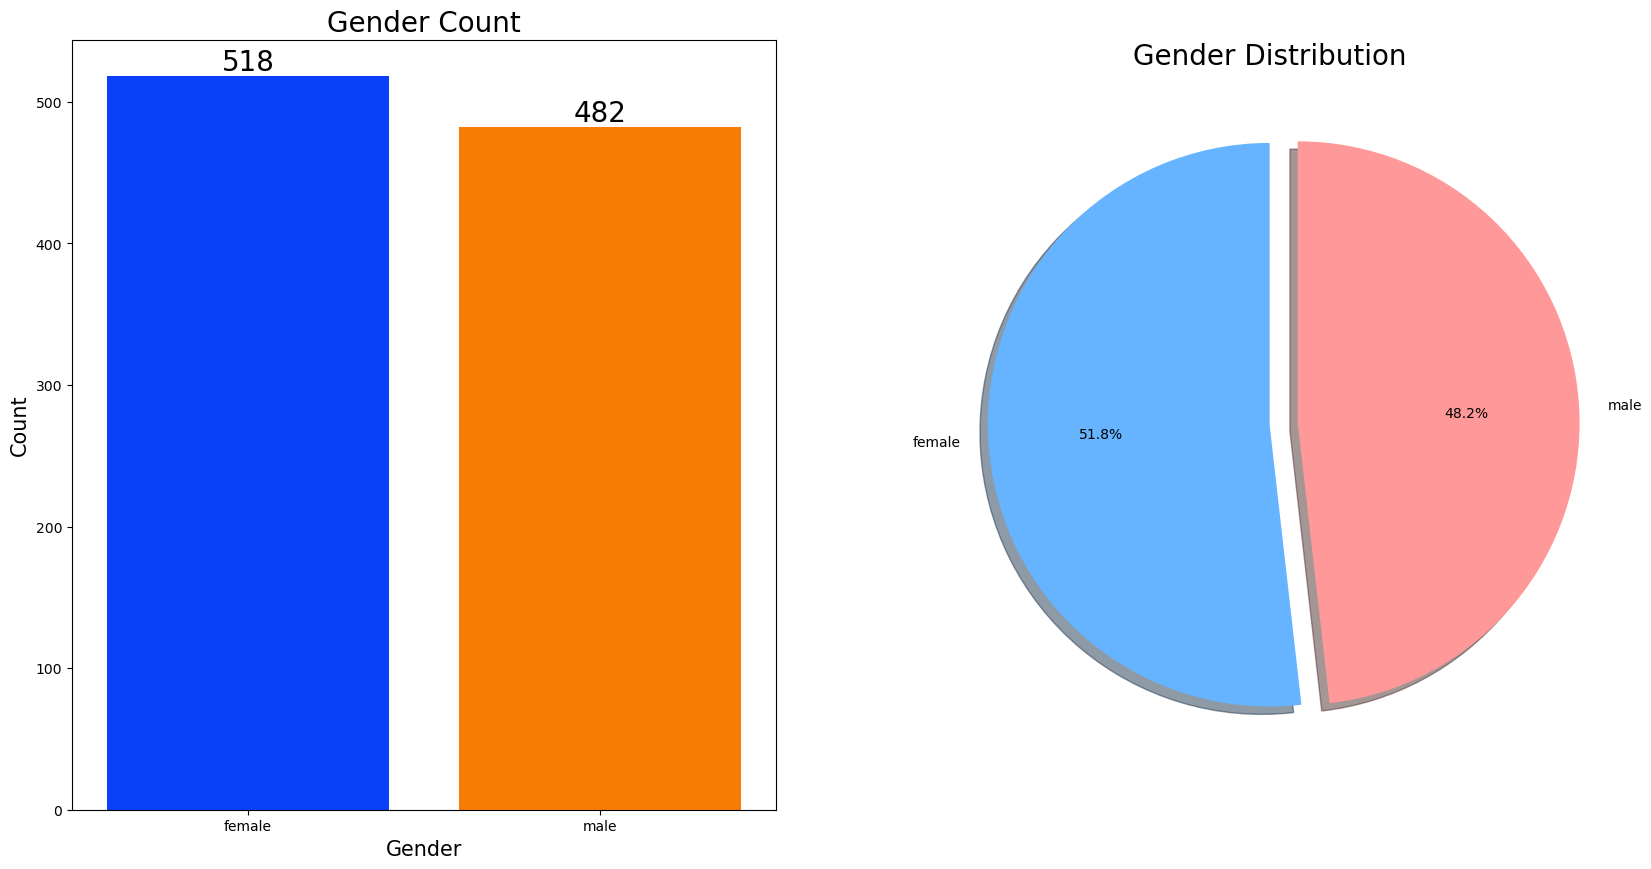

In [74]:
f, ax = plt.subplots(1, 2, figsize=(20, 10))

# --- Bar Plot ---
sns.countplot(x='gender', data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
ax[0].set_title('Gender Count', fontsize=20)
ax[0].set_xlabel('Gender', fontsize=15)
ax[0].set_ylabel('Count', fontsize=15)

# --- Pie Chart ---
gender_counts = df['gender'].value_counts()
ax[1].pie(
    x=gender_counts,
    labels=gender_counts.index,
    explode=[0, 0.1],
    autopct='%1.1f%%',
    shadow=True,
    colors=['#66b3ff', '#ff9999'],
    startangle=90
)
ax[1].set_title('Gender Distribution', fontsize=20)

plt.show()

## Bivariate Analysis

In [76]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group


,math score,reading score,writing score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483
